# Project 03: Gibbs Sampling (Random Algorithm)

In [1]:
import random
import numpy as np
import seqlogo 
#import function for building sequence motif & idenfitying seqs matching to motif
from data_readers import *
from seq_ops import get_seq
from motif_ops import *

ModuleNotFoundError: No module named 'data_readers'

---
# Project Start

In [ ]:
def GibbsMotifFinder (seqs, k, seed=None):
    '''
    Function to find a pfm from a list of strings using a Gibbs sampler
    
    Args: 
        seqs (str list): a list of sequences, not necessarily in same lengths
        k (int): the length of motif to find
        seed (int, default=None): seed for np.random

    Returns:
        pfm (numpy array): dimensions are 4xlength

    Pseudocode:

    1. INITIALIZE
    Pick a random start position m in each N sequence (using np.random) -> numpy.random.choice()
        needs to be a postion that fits length k motif, cannot cut motif in half
    Calculate frequency of every nucleotide at each mosition within the motif for all chosen motifs in all the N sequences
    # No need to do this step, assume fixed prob of 0.25 per base : Calculate frequency of every non-motif positionin all N sequences as background

    2. ITERATE    
        Hold out one of the sequences i randomly -> numpy.random.randint()
        build pfm from list of sequences N-1 with length k -> build_pfm(sequences: List[str], length: int)
        build pwm from above pfm with omitted sequence i  -> build_pwm(pfm: np.ndarray)
        score every start position kmer for entire length of held out sequence i against the new pwm -> score_kmer(seq i: str, pwm: np.ndarray)
        with returned pwm score (float) for k-mer, calculate information content (float) of pfm -> pfm_ic(pfm: np.ndarray). return IC = pfm_ic(pfm)
    repeat for every sequence being withheld, randomly choosign sequence i, until all N sequences have gone through the scoring
            choose a new motif based on score distribution (don't use max (local vs global))
            DO RANDOM WITH A WEIGHT, UNDO THE LOG2 (so no neg values)

    flip the strand and repeat above loop for negative strand as well as positive -> reverse_complement(seq) #where to place this? - inside scoring step

    3. CONVERGENCE CHECK
    run until score of model reaches convergence or maximum iterations occur -> for j <-1 to 10,000 or Motifs stop changing

    4. RETURN FINAL PFM

    NOTES:
    random pick of k-length sequences from each line of DNA as motifs
    for j <-1 to 10,000 or Motifs stop changing
        i <- random(N) where N is number of DNA entries
        PWM <- PWM constructed from all Motifs except Motifi
        Motifi <- select position m from PWM-scored k-mers in DNAi in probabalistic fashion from score distribution 
    return PFM

    ---------------------------------------

    1. INITIALIZE
    FOR each seq i in seqs:
        pick a random valid start position m (0 <= m <= len(seq_i) - k)
           -> rng.integers(0, len(seq_i) - k + 1)
       motif_i <- seq_i[m : m+k]
   motifs <- [motif_1, ..., motif_N]  #build list of motifs 

   2. ITERATE
   FOR j in 1..max_iter, or until motifs stop changing:
   seq i <- rng.integers(0, N)                      
   pfm_others <- build_pfm(motifs minus motif_i, k)
   pwm <- build_pwm(pfm_others)
   For every valid start position p in seqs[i] (and for also every valid start position in reverse_complement(seqs[i])):
          forward chunk <- score_kmer(seqs[i][p:p+k], pwm)
          reverse chunk ,_

   Convert scores -> probability distribution and sample a new start position and strand i from that distribution
   Replace motif_i with the newly sampled k-mer (from + or - strand)

   3. CONVERGENCE CHECK
    Track pfm_ic(build_pfm(motifs, k)) each iteration (or every few iterations)
    Stop early if IC stops improving or motifs stop changing, otherwise stop at max_iter (e.g. 10,000).

    4. RETURN
    final_pfm <- build_pfm(motifs, k)
    return final_pfm

-------------------------FINAL Pseudocode Ildiko----------------------------------------
    #FUNCTION GibbsMotifFinder(seqs, k, seed)

    #Setup (before the loop)
        #Initialize random seed:  Already done in the code above
        #Motifs = a list that will hold the current guessed chunk (string) for each sequence
        #FOR each sequence in seqs:
            #pick a random starting position between 0 and sequence length - k
            #grab the k-length chunk starting at that position
            #save this chunk as the current guess for this sequence

    #Main Loop (5 basics steps of Gibbs Sampling)
        #REPEAT up to 10,000 times:
            #Randomly pick one sequence to leave out
            #Build a consensus (PFM/PWM) from all guesses in Motifs except sequence i
                #pfm = build_pfm(all Motifs except Motifs[i])
                #pwm = build_pwm(pfm)
            #Score every possible position in the "left out" sequence i, checking both strands:
                #FOR each valid starting position in sequence i:
                    #forward_chunk = the k-length chunk at this position
                    #reverse_chunk = reverse_complement(forward_chunk)
                    #forward_score = score_kmer(forward_chunk, pwm)
                    #reverse_score = score_kmer(reverse_chunk, pwm)
                    #keep the higher of forward_score/reverse_score and remember which it is
                        #this gives a list of best scores (and matching chunks), one per position
            
            #Convert scores into weights, since scores are log2-based and can be negative
                #weights = 2^(score) for each score in the list (undoes log2)
                #turns scores back into positive usable probability
            
            #Pick a new position for sequence i, randomly weighted by score
                #use np.random.choice, weighted by the converted weights and not picking single highest scoring position
            
            #Update Motifs[i] to the chunck (forward or reverse complement) that corresponds to newly picked position

    #After the Loop
        #Build one final PFM table using all Motifs 
            #final_pfm = build_pfm(Motifs)
        #Return final_PFM


    '''

    max_iter = 10000

    # Use rng to make random samples/selections/numbers
    # Example: randint = rng.integer(1, 10)
    random.seed(seed)
    rng = np.random.default_rng(seed)
    total_seqs = len(seqs) #N, total number of seqs

 
    # INITIALIZE random valid start position per sequence
    motifs = []
    for seq in seqs:
        start_pos = rng.integers(0, len(seq) - k + 1) #picks a start position at random
        motifs.append(seq[start_pos:start_pos + k]) # hold one k length chunk per seq

    print(f"num sequences: {total_seqs}")
    print(f"first 3 motifs: {motifs[:3]}")
    print(f"motif lengths all == k? {all(len(m) == k for m in motifs)}")
 
    # save the best scoring version of 4xk frequency matrix
    final_ic = -np.inf 
    final_pfm = build_pfm(motifs, k)
    print(f"initial pfm shape: {final_pfm.shape}")  # should be (4, k)
    print(f"initial pfm:\n{final_pfm}")
    stall_count = 0 # count how many iterations in a row that have failed improving
 
    for j in range(max_iter):
        # hold out one random sequence i
        i = rng.integers(0, total_seqs)
 
        # build pfm/pwm from all OTHER current motifs
        other_motifs = motifs[:i] + motifs[i + 1:]
        pfm_others = build_pfm(other_motifs, k) 
        pwm = build_pwm(pfm_others)

        if j % 500 == 0:
            print(f"\n--- iteration {j} ---")
            print(f"held-out seq index: {i}")
            print(f"pwm shape: {pwm.shape}")
 
        # score every position in the held out sequence, both strands, keeping the better scoring chunk at each position
        seq_i = seqs[i]
        possible_pos = len(seq_i) - k + 1 # grabs all possible k-length start positions within the held out seq i

        best_scores = np.empty(possible_pos) #create numpy array of length possible_pos
        best_chunks = []
 
        for pos in range(possible_pos):
            forward_chunk = seq_i[pos:pos + k]
            reverse_chunk = reverse_complement(forward_chunk)
            forward_score = score_kmer(forward_chunk, pwm)
            reverse_score = score_kmer(reverse_chunk, pwm)
 
            if forward_score >= reverse_score:
                best_scores[pos] = forward_score
                best_chunks.append(forward_chunk)
            else:
                best_scores[pos] = reverse_score
                best_chunks.append(reverse_chunk)
 
        # undo log2, positive weights, normalize to probabilities
        weights = np.power(2.0, best_scores)
        probs = weights / weights.sum()

        if j % 500 == 0:
            print(f"num candidate positions: {possible_pos}")
            print(f"best_scores range: {best_scores.min():.3f} to {best_scores.max():.3f}")
 
        # weighted random pick (NOT max), update motif i
        chosen_pos = rng.choice(possible_pos, p=probs)
        motifs[i] = best_chunks[chosen_pos]
 
        if j % 500 == 0:
            print(f"chosen position: {chosen_pos}, new motif_i: {motifs[i]}")

        # convergence tracking
        tolerance = 1e-6 # removes requirement for exact floating points for ic and final_ic to be equal
        full_pfm = build_pfm(motifs, k)
        ic = pfm_ic(full_pfm)
        if ic > final_ic + tolerance:
            final_ic = ic
            final_pfm = full_pfm
            stall_count = 0
        else:
            stall_count += 1

        if j % 500 == 0:
            print(f"ic: {ic:.4f}, final_ic: {final_ic:.4f}, stall_count: {stall_count}")

 
        if stall_count >= 500:  
            print(f"Converged early at iteration {j}")
            break
 
    print(f"\nfinal IC: {final_ic:.4f}")
    print(f"final pfm:\n{final_pfm}")
    return final_pfm


In [ ]:
# Here we test your Gibbs sampler.
# You do not need to edit this or the section below. This is the Driver program

#read promoters, store in a list of strings
seq_file="/Users/juliannemurthy/Downloads/project03(1)/data/GCF_000009045.1_ASM904v1_genomic.fna"
gff_file="/Users/juliannemurthy/Downloads/project03(1)/data/GCF_000009045.1_ASM904v1_genomic.gff"

seqs = []

for name, seq in get_fasta(seq_file): # For each entry in our FASTA file
    for gff_entry in get_gff(gff_file): # For each entry in our GFF file
        if gff_entry.type == 'CDS': # If this is a coding sequence
            promoter_seq = get_seq(seq, gff_entry.start, gff_entry.end, gff_entry.strand, 50) # Extract 50 bp as a promoter
    
            """
            Because the gibbs sampling assumption is broken in just using promoters,
            and because it takes very long time to randomly progress through so many
            regions, for this example we will pre-filter for sequences that all contain
            part of the shine-dalgarno motif:
            """
            if "AGGAGG" in promoter_seq:
                seqs.append(promoter_seq)

---
# Driver Program
Don't change any of the code here. If you have completed the project by following the coding by contract, the following code should work.

In [ ]:
# Run the gibbs sampler:
promoter_pfm = GibbsMotifFinder(seqs,10 )

# Plot the final pfm that is generated: 
seqlogo.seqlogo(seqlogo.CompletePm(pfm = promoter_pfm.T))


num sequences: 837
first 3 motifs: ['AGGAGGGACG', 'GTTAGGAGGA', 'AAGGAGGATT']
motif lengths all == k? True
initial pfm shape: (4, 10)
initial pfm:
[[336 274 313 309 318 297 290 310 301 309]
 [101 116 121 118 116 110 125 118 113 115]
 [181 235 204 216 218 209 213 204 200 190]
 [219 212 199 194 185 221 209 205 223 223]]

--- iteration 0 ---
held-out seq index: 630
pwm shape: (4, 10)
num candidate positions: 41
best_scores range: -2.580 to 2.407
any inf/nan in weights? False
probs sum to 1? True
chosen position: 8, new motif_i: CCGAGAATGA
ic: 0.7916, final_ic: 0.7916, stall_count: 0

--- iteration 500 ---
held-out seq index: 639
pwm shape: (4, 10)
num candidate positions: 41
best_scores range: -1.754 to 5.034
any inf/nan in weights? False
probs sum to 1? True
chosen position: 12, new motif_i: TATAATGAAA
ic: 1.5859, final_ic: 1.5863, stall_count: 1

--- iteration 1000 ---
held-out seq index: 291
pwm shape: (4, 10)
num candidate positions: 41
best_scores range: -4.379 to 6.714
any inf/nan i

---
# NRF1 Driver Program
Modify the code below and test your Gibbs Sampler.

num sequences: 90061
first 3 motifs: ['TATTATATAA', 'GAGACACATG', 'ATGTTGTGTA']
motif lengths all == k? True
initial pfm shape: (4, 10)
initial pfm:
[[19807 19653 19514 19481 19404 19267 19382 19678 19431 19629]
 [25567 25503 25498 25580 25668 25349 25575 25323 25630 25359]
 [25276 25545 25474 25600 25512 25765 25734 25487 25529 25552]
 [19411 19360 19575 19400 19477 19680 19370 19573 19471 19521]]

--- iteration 0 ---
held-out seq index: 47488
pwm shape: (4, 10)
num candidate positions: 66
best_scores range: -0.471 to 1.473
any inf/nan in weights? False
probs sum to 1? True
chosen position: 9, new motif_i: GCGACGGGCG
ic: 0.1296, final_ic: 0.1296, stall_count: 0

--- iteration 500 ---
held-out seq index: 83139
pwm shape: (4, 10)
num candidate positions: 66
best_scores range: -1.671 to 0.730
any inf/nan in weights? False
probs sum to 1? True
chosen position: 56, new motif_i: GAGGGTGACA
ic: 0.1307, final_ic: 0.1307, stall_count: 0

--- iteration 1000 ---
held-out seq index: 26351
pwm sha

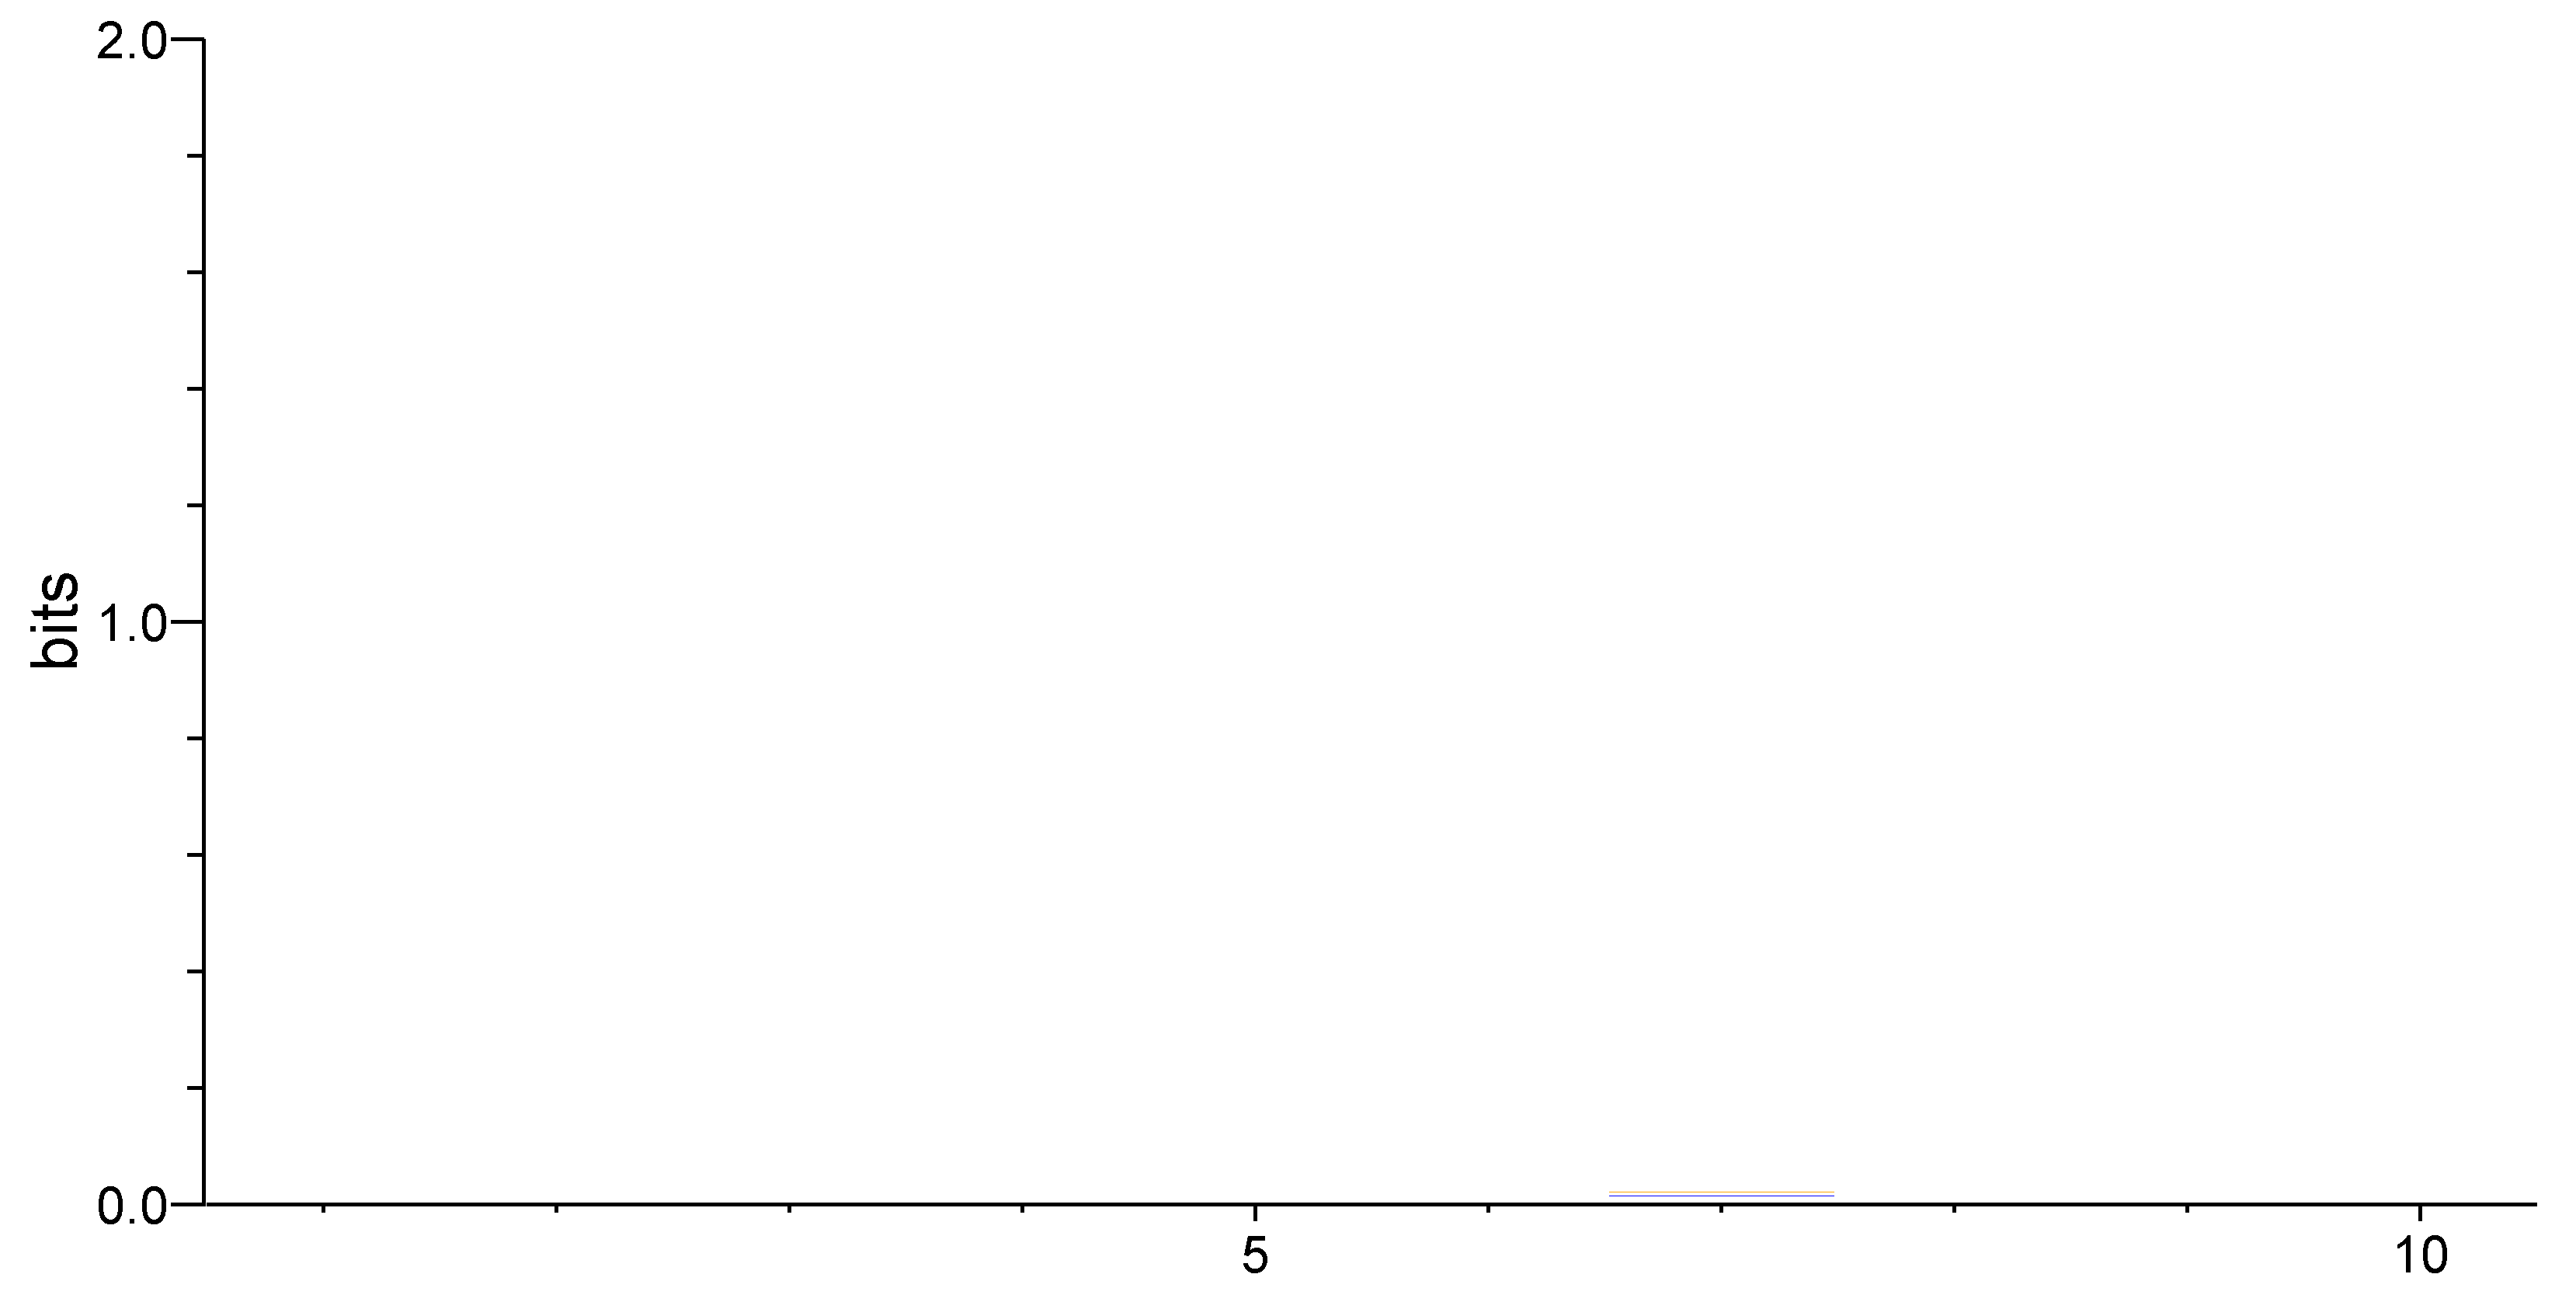

In [ ]:
# Here we test your Gibbs sampler.
# You do not need to edit this or the section below. This is the Driver program

'''
Psuedocode: 
nrf1_file="<path/to/file.fa>"
nrf1_peaks = []

FOR name, seq in get_fasta(nrf1_file):
nrf1_peaks.append(seq)
    


'''

#read promoters, store in a list of strings
nrf1_file="/Users/juliannemurthy/Downloads/project03(1)/data/nrf1_gibbs.fa"

nrf1_peaks = []

for name, seq in get_fasta(nrf1_file):
    nrf1_peaks.append(seq)


# Run the gibbs sampler:
nrf1_pfm = GibbsMotifFinder(nrf1_peaks, 10)

# Plot the final pfm that is generated: 
#seqlogo.seqlogo(seqlogo.CompletePm(pfm = nrf1_pfm.T)) #Note: comment out to remove empty graph because of GhostScript

#sanity check our results without in case seqlogo in NRF1 Driver Program doesn't work
#Note: NRF1 has ~90,000 sequences (versus ~800 for promoters), so it will take a long time to run 10,000 rounds.  
#A quick 100 round test showed working code but a low IC score, which is expected for just a few rounds
print(nrf1_pfm)
print(pfm_ic(nrf1_pfm))